In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import joblib

print("Libraries imported successfully.")

2026-05-14 17:14:18.306963: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778778858.710396      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778778858.824168      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778778859.796305      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778778859.796350      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778778859.796353      57 computation_placer.cc:177] computation placer alr

Libraries imported successfully.


In [3]:
def process_data_final(file_path, num_points=100):
    if not os.path.exists(file_path):
        raise FileNotFoundError(f'File not found: {file_path}')

    df = pd.read_csv(file_path, on_bad_lines='skip', skip_blank_lines=True, low_memory=False)
    df.columns = df.columns.str.strip()

    # Base features from CSV
    X_base_features = ['Length', 'Diameter', 'Core_Diameter', 'Rod_Diameter', 'Support_Diameter', 'Throat_Diameter', 'Exit_Diameter']
    scalar_cols = ['ISP (s)', 'Total Impulse (Ns)']
    
    time_col, thrust_col, pressure_col = 'Time (s)', 'Thrust (N)', 'Pressure (MPa)'
    numeric_columns = ['ID', time_col, thrust_col, pressure_col] + X_base_features + scalar_cols

    for col in numeric_columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    df.dropna(subset=numeric_columns, axis=0, inplace=True)
    ids = df['ID'].unique()
    X, y_thrust, y_pressure, y_scalars = [], [], [], []

    for uid in ids:
        try:
            case_data = df[df['ID'] == uid].sort_values(time_col)
            base_inputs = case_data[X_base_features].iloc[0].values
            
            # --- Physics-Based Feature Engineering ---
            throat_dia = case_data['Throat_Diameter'].iloc[0]
            exit_dia = case_data['Exit_Diameter'].iloc[0]
            throat_area = np.pi * (throat_dia / 2)**2
            exit_area = np.pi * (exit_dia / 2)**2
            
            # Combine to create 9 features instead of 7
            enhanced_inputs = np.append(base_inputs, [throat_area, exit_area])
            
            t = case_data[time_col].values
            if len(t) < 5 or t[-1] <= 0: continue

            thrust = case_data[thrust_col].values
            pressure = case_data[pressure_col].values

            x_new = np.linspace(t[0], t[-1], num_points)
            X.append(enhanced_inputs)
            y_thrust.append(interp1d(t, thrust, kind='linear', fill_value='extrapolate')(x_new))
            y_pressure.append(interp1d(t, pressure, kind='linear', fill_value='extrapolate')(x_new))
            y_scalars.append([case_data['ISP (s)'].iloc[0], case_data['Total Impulse (Ns)'].iloc[0], t[-1], np.max(thrust)])
        except: continue

    return np.array(X), np.array(y_thrust), np.array(y_pressure), np.array(y_scalars)

In [23]:
data =pd.read_csv("/kaggle/input/datasets/abdoamrrrr/new-roda-and-tube/Rocket_Results_Full_Data.csv")
data.tail()

,Time (s),Pressure (MPa),Thrust (N),ID,Length,Diameter,Core_Diameter,Rod_Diameter,Support_Diameter,Throat_Diameter,Exit_Diameter,Total Impulse (Ns),ISP (s),Max Thrust (N),Peak Pressure (MPa),Burn Time (s),Avg Thrust (N)
4651165,8.460,45.8787,41341.2881,3720,130,20,4,1,0,2.9,4.35,122581.397,174.696,41525.021,46.082,8.48,14446.835
4651166,8.465,45.9463,41402.4511,3720,130,20,4,1,0,2.9,4.35,122581.397,174.696,41525.021,46.082,8.48,14446.835
4651167,8.470,46.0141,41463.6953,3720,130,20,4,1,0,2.9,4.35,122581.397,174.696,41525.021,46.082,8.48,14446.835
4651168,8.475,46.0819,41525.0207,3720,130,20,4,1,0,2.9,4.35,122581.397,174.696,41525.021,46.082,8.48,14446.835
4651169,8.480,0.0000,0.0000,3720,130,20,4,1,0,2.9,4.35,122581.397,174.696,41525.021,46.082,8.48,14446.835


In [231]:
# import os

# # Install Kaggle API client
# !pip install kaggle

# # Ensure kaggle.json is in the correct directory for authentication
# # This is typically done by uploading kaggle.json to /content/ or ~/.kaggle/
# # Given kaggle.json is listed in /content/, we assume it's set up.

# # Set permissions for the kaggle.json file
# !mkdir -p ~/.kaggle
# !cp /content/kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json

In [232]:
# # Download the dataset from Kaggle
# # Dataset: abdoamrrrr/rode-and-tube-1
# !kaggle datasets download -d abdoamrrrr/rode-and-tube-1 -p /content/

# # Unzip the downloaded file
# # The downloaded file will likely be named 'rode-and-tube-1.zip'
# zip_file_path = '/content/rode-and-tube-1.zip'
# extract_to_directory = '/content/'

# import zipfile
# import os

# if os.path.exists(zip_file_path):
#     with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
#         zip_ref.extractall(extract_to_directory)
#     print(f"✅ Successfully extracted {zip_file_path} to {extract_to_directory}")
#     # List files to verify extraction and find the CSV name
#     print("Files in extraction directory:")
#     print(os.listdir(extract_to_directory))
# else:
#     print(f"❌ Zip file not found: {zip_file_path}")

In [5]:
FILE_PATH = "/kaggle/input/datasets/abdoamrrrr/new-roda-and-tube/Rocket_Results_Full_Data.csv" 

X, Y_t, Y_p, Y_s = process_data_final(FILE_PATH)

# Scaling Curves
scaler_t = StandardScaler()
Y_t_scaled = scaler_t.fit_transform(Y_t.reshape(-1, 1)).reshape(Y_t.shape)
scaler_p = StandardScaler()
Y_p_scaled = scaler_p.fit_transform(Y_p.reshape(-1, 1)).reshape(Y_p.shape)

# Split Data
X_train, X_test, Yt_train, Yt_test, Yp_train, Yp_test, Ys_train, Ys_test = train_test_split(
    X, Y_t_scaled, Y_p_scaled, Y_s, test_size=0.15, random_state=42
)

# Scaling Inputs (Now with 9 features) & Scalars
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_Ys = StandardScaler()
Ys_train_scaled = scaler_Ys.fit_transform(Ys_train)

# Save Scalers
joblib.dump(scaler_X, 'scaler_X.pkl')
joblib.dump(scaler_Ys, 'scaler_Ys.pkl')
joblib.dump(scaler_t, 'scaler_t.pkl')
joblib.dump(scaler_p, 'scaler_p.pkl')

print(f"✅ Data prepared. Input shape: {X_train_scaled.shape[1]} features.")

✅ Data prepared. Input shape: 9 features.


In [6]:
# --- Cell 4: Back to Basics (Clean MAE Architecture) ---
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam

def build_clean_model(input_shape, time_steps=100):
    inputs = layers.Input(shape=(input_shape,))
    
    # --- Shared Encoder ---
    x = layers.Dense(512)(inputs)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = layers.BatchNormalization()(x)
    
    x = layers.Dense(1024)(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Dense(512)(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)

    # --- Scalars (For perfect Total Impulse) ---
    s = layers.Dense(256)(x)
    s = layers.LeakyReLU(negative_slope=0.1)(s)
    s = layers.Dense(128)(s)
    scalar_output = layers.Dense(4, name='scalars')(s)
    
    # --- Curves (Shared intelligence) ---
    c = layers.Dense(1024)(x)
    c = layers.LeakyReLU(negative_slope=0.1)(c)
    c = layers.Dense(1024)(c)
    c = layers.LeakyReLU(negative_slope=0.1)(c)
    
    thrust_output = layers.Dense(time_steps, name='thrust')(c)
    pressure_output = layers.Dense(time_steps, name='pressure')(c)
    
    model = Model(inputs=inputs, outputs=[thrust_output, pressure_output, scalar_output])
    return model

model = build_clean_model(X_train_scaled.shape[1], 100)

# --- THE REAL FIX: MAE Loss ---
model.compile(
    optimizer=Adam(learning_rate=0.0005), 
    loss={
        'thrust': 'mae',     
        'pressure': 'mae',   
        'scalars': 'mse'     
    },
    loss_weights={
        'thrust': 15.0,    
        'pressure': 15.0,  
        'scalars': 50.0    
    }
)

print("✅ Model compiled cleanly with MAE for sharp, zigzag-free edges.")

I0000 00:00:1778778970.480518      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778778970.486272      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


✅ Model compiled cleanly with MAE for sharp, zigzag-free edges.


In [7]:
# --- Cell 5: Stable Training ---
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=60, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=15, min_lr=1e-7)

history = model.fit(
    X_train_scaled, 
    {'thrust': Yt_train, 'pressure': Yp_train, 'scalars': Ys_train_scaled},
    validation_split=0.15,
    epochs=1200, 
    batch_size=32, 
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

model.save('rocket_motor_golden.keras')
print("✅ Training completed smoothly.")

Epoch 1/1200


I0000 00:00:1778778975.593272     131 service.cc:152] XLA service 0x7a23900291e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778778975.593306     131 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778778975.593322     131 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778778976.259372     131 cuda_dnn.cc:529] Loaded cuDNN version 91002


45/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 48.0192 - pressure_loss: 0.3861 - scalars_loss: 0.7305 - thrust_loss: 0.3802

I0000 00:00:1778778978.885425     131 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


84/84 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - loss: 36.5556 - pressure_loss: 0.3241 - scalars_loss: 0.5385 - thrust_loss: 0.3178 - val_loss: 59.8537 - val_pressure_loss: 0.5615 - val_scalars_loss: 0.8604 - val_thrust_loss: 0.5659 - learning_rate: 5.0000e-04
Epoch 2/1200
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 10.9397 - pressure_loss: 0.1658 - scalars_loss: 0.1197 - thrust_loss: 0.1644 - val_loss: 53.0332 - val_pressure_loss: 0.5107 - val_scalars_loss: 0.7552 - val_thrust_loss: 0.5136 - learning_rate: 5.0000e-04
Epoch 3/1200
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.7176 - pressure_loss: 0.1372 - scalars_loss: 0.0900 - thrust_loss: 0.1439 - val_loss: 45.6439 - val_pressure_loss: 0.4505 - val_scalars_loss: 0.6424 - val_thrust_loss: 0.4585 - learning_rate: 5.0000e-04
Epoch 4/1200
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.9608 - pressure_loss: 0.1540 - scalars_loss: 0.0878 - thrust_loss: 0.1506 - val_loss: 36.6388 - val_pressure_loss: 0.3834 - val_scalars_loss: 0.5033 - v

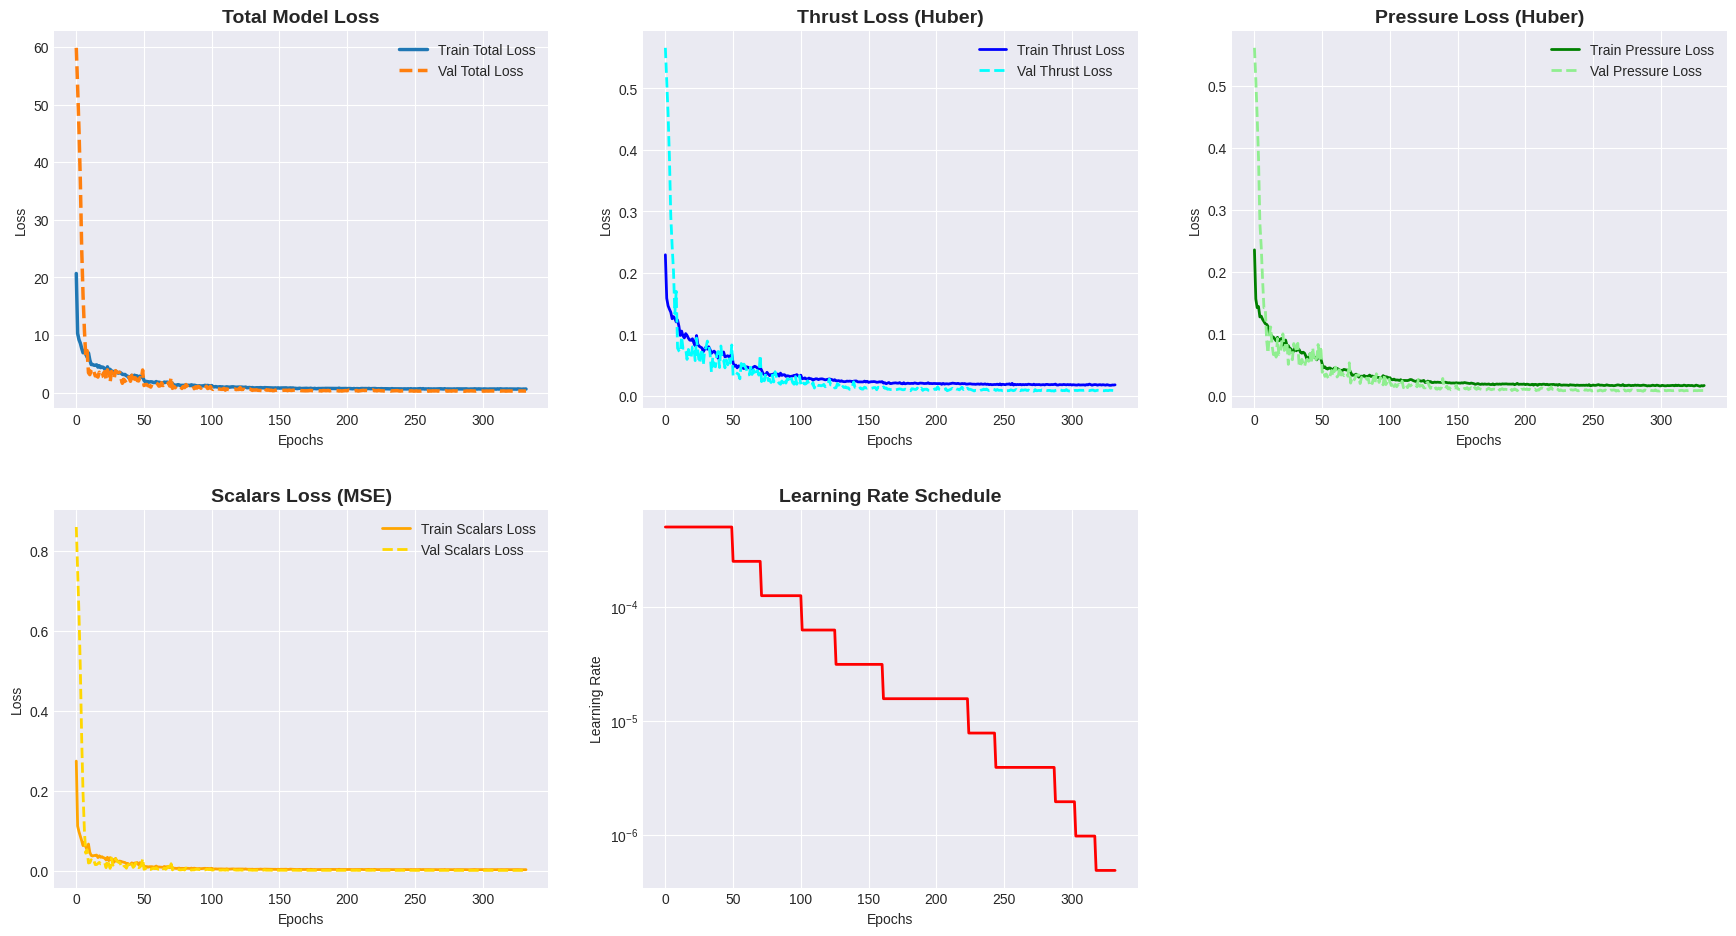

In [8]:
# 1. Fetch dictionary keys recorded during training
h_keys = history.history.keys()

# Helper function to find the correct key (handles naming variations in Keras)
def get_key(base_name):
    for k in h_keys:
        if base_name.lower() in k.lower() and 'val' not in k.lower():
            return k
    return None

def get_val_key(base_name):
    for k in h_keys:
        if base_name.lower() in k.lower() and 'val' in k.lower():
            return k
    return None

# Extract specific keys for our outputs
k_thrust = get_key('thrust')
k_val_thrust = get_val_key('thrust')

k_pressure = get_key('pressure')
k_val_pressure = get_val_key('pressure')

k_scalars = get_key('scalars')
k_val_scalars = get_val_key('scalars')

# Determine learning rate key
lr_key = 'learning_rate' if 'learning_rate' in h_keys else ('lr' if 'lr' in h_keys else None)

# ================== Start Plotting ==================
plt.figure(figsize=(18, 10))
try:
    plt.style.use('seaborn-v0_8-darkgrid') 
except:
    plt.style.use('seaborn-darkgrid')

# 1. Total Model Loss
plt.subplot(2, 3, 1)
plt.plot(history.history['loss'], label='Train Total Loss', linewidth=2.5, color='#1f77b4')
if 'val_loss' in h_keys:
    plt.plot(history.history['val_loss'], label='Val Total Loss', linewidth=2.5, color='#ff7f0e', linestyle='--')
plt.title('Total Model Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# 2. Thrust Loss
if k_thrust:
    plt.subplot(2, 3, 2)
    plt.plot(history.history[k_thrust], label='Train Thrust Loss', color='blue', linewidth=2)
    if k_val_thrust:
        plt.plot(history.history[k_val_thrust], label='Val Thrust Loss', color='cyan', linestyle='--', linewidth=2)
    plt.title('Thrust Loss (Huber)', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

# 3. Pressure Loss
if k_pressure:
    plt.subplot(2, 3, 3)
    plt.plot(history.history[k_pressure], label='Train Pressure Loss', color='green', linewidth=2)
    if k_val_pressure:
        plt.plot(history.history[k_val_pressure], label='Val Pressure Loss', color='lightgreen', linestyle='--', linewidth=2)
    plt.title('Pressure Loss (Huber)', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

# 4. Scalars Loss (ISP, Impulse, etc.)
if k_scalars:
    plt.subplot(2, 3, 4)
    plt.plot(history.history[k_scalars], label='Train Scalars Loss', color='orange', linewidth=2)
    if k_val_scalars:
        plt.plot(history.history[k_val_scalars], label='Val Scalars Loss', color='gold', linestyle='--', linewidth=2)
    plt.title('Scalars Loss (MSE)', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

# 5. Learning Rate Decay
if lr_key:
    plt.subplot(2, 3, 5)
    plt.plot(history.history[lr_key], color='red', linewidth=2)
    plt.title('Learning Rate Schedule', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Learning Rate')
    plt.yscale('log') # Log scale to see small changes

plt.tight_layout(pad=3.0)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 658ms/step


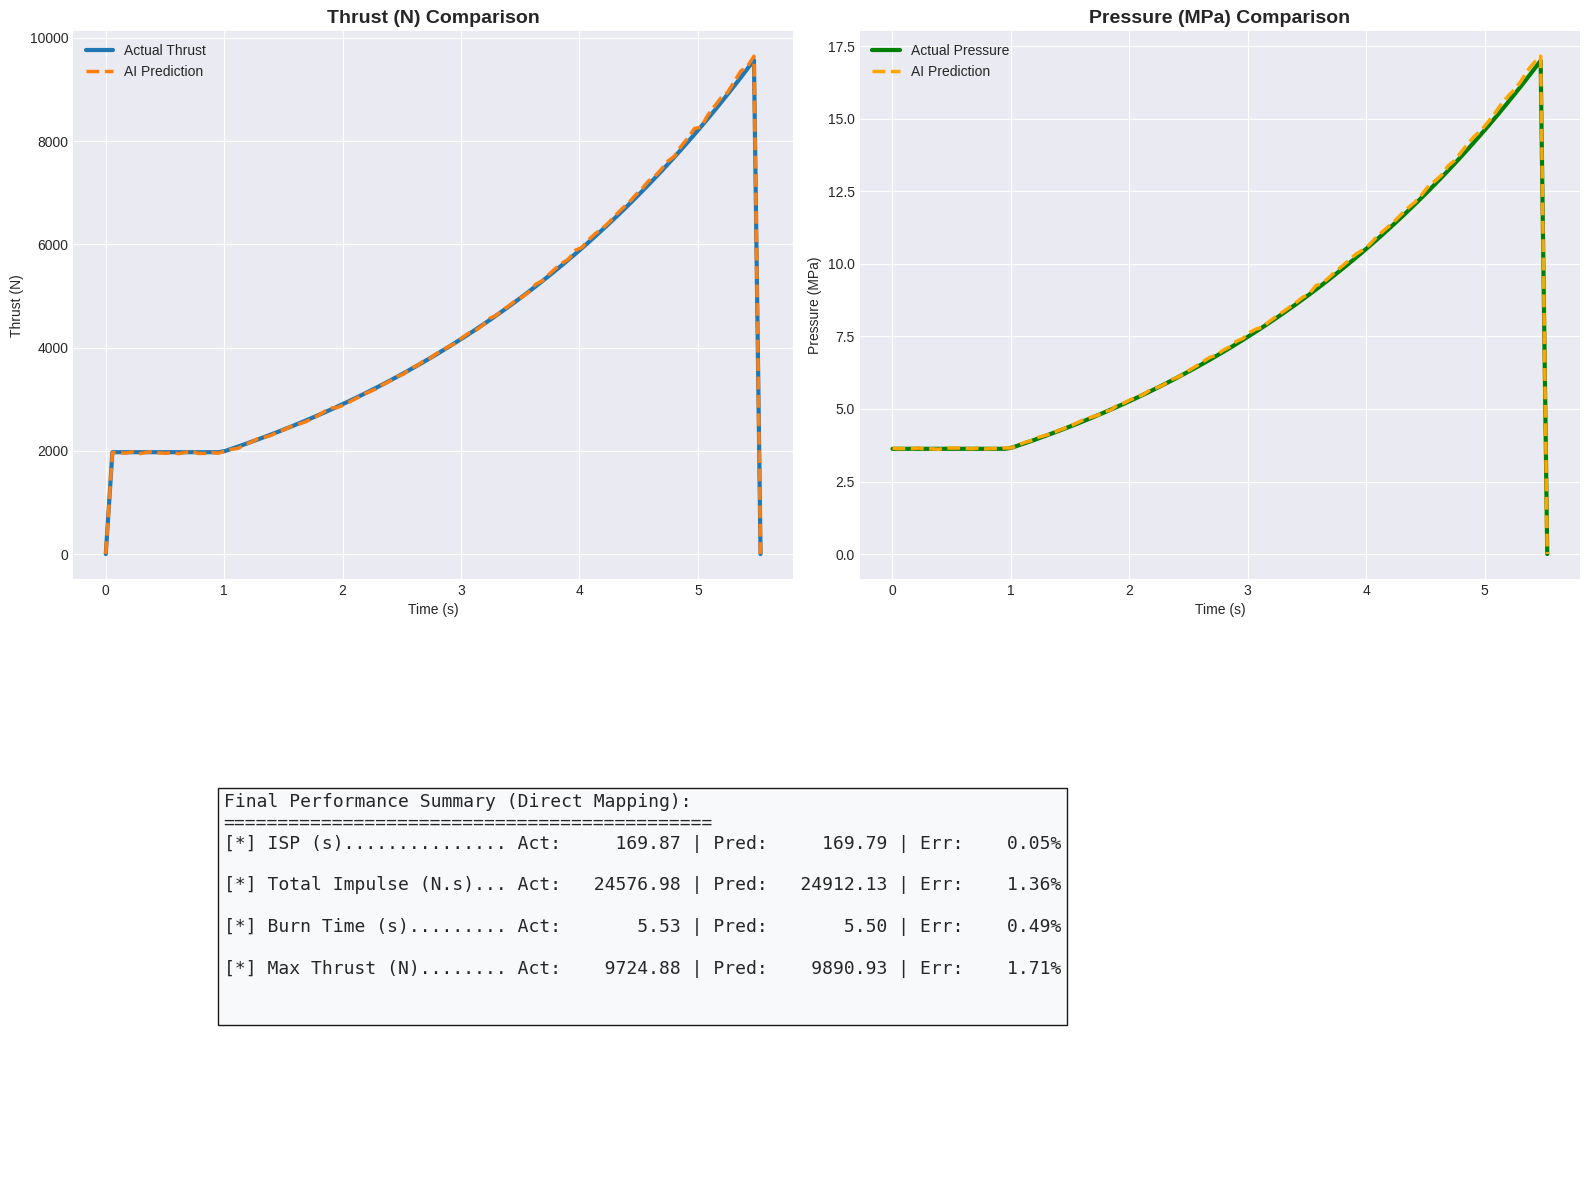

In [9]:
# --- Cell 6: Evaluation and Visualization ---
# 1. Select sample index
sample_idx = 10 
sample_input = X_test_scaled[sample_idx:sample_idx+1]

# 2. Get AI Predictions
predictions = model.predict(sample_input)

# 3. Inverse transform (Back to real physical units)
pred_thrust = scaler_t.inverse_transform(predictions[0][0].reshape(-1, 1)).flatten()
pred_pressure = scaler_p.inverse_transform(predictions[1][0].reshape(-1, 1)).flatten()
pred_scalars = scaler_Ys.inverse_transform(predictions[2])[0] 

# 4. Actual Values
act_thrust = scaler_t.inverse_transform(Yt_test[sample_idx].reshape(-1, 1)).flatten()
act_pressure = scaler_p.inverse_transform(Yp_test[sample_idx].reshape(-1, 1)).flatten()
act_scalars = Ys_test[sample_idx]

# 5. Setup Time Axis
time_axis = np.linspace(0, act_scalars[2], 100)

# 6. Plotting (No smoothing used to show the raw power of the model)
plt.figure(figsize=(16, 12))
plt.style.use('seaborn-v0_8-darkgrid')

# Thrust Plot
plt.subplot(2, 2, 1)
plt.plot(time_axis, act_thrust, label='Actual Thrust', linewidth=3)
plt.plot(time_axis, np.maximum(0, pred_thrust), '--', label='AI Prediction', linewidth=2.5)
plt.title('Thrust (N) Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Time (s)')
plt.ylabel('Thrust (N)')
plt.legend()

# Pressure Plot
plt.subplot(2, 2, 2)
plt.plot(time_axis, act_pressure, color='green', label='Actual Pressure', linewidth=3)
plt.plot(time_axis, np.maximum(0, pred_pressure), '--', color='orange', label='AI Prediction', linewidth=2.5)
plt.title('Pressure (MPa) Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Time (s)')
plt.ylabel('Pressure (MPa)')
plt.legend()

# Accuracy Summary Table
plt.subplot(2, 1, 2)
plt.axis('off')
labels = ['ISP (s)', 'Total Impulse (N.s)', 'Burn Time (s)', 'Max Thrust (N)']
summary_text = "Final Performance Summary (Direct Mapping):\n" + "="*45 + "\n"

for i, label in enumerate(labels):
    error = abs(pred_scalars[i] - act_scalars[i]) / (abs(act_scalars[i]) + 1e-9) * 100
    summary_text += f"[*] {label:.<22} Act: {act_scalars[i]:>10.2f} | Pred: {pred_scalars[i]:>10.2f} | Err: {error:>7.2f}%\n\n"

plt.text(0.1, 0.5, summary_text, fontsize=13, family='monospace', va='center', bbox=dict(facecolor='#f8f9fa', alpha=0.9))
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


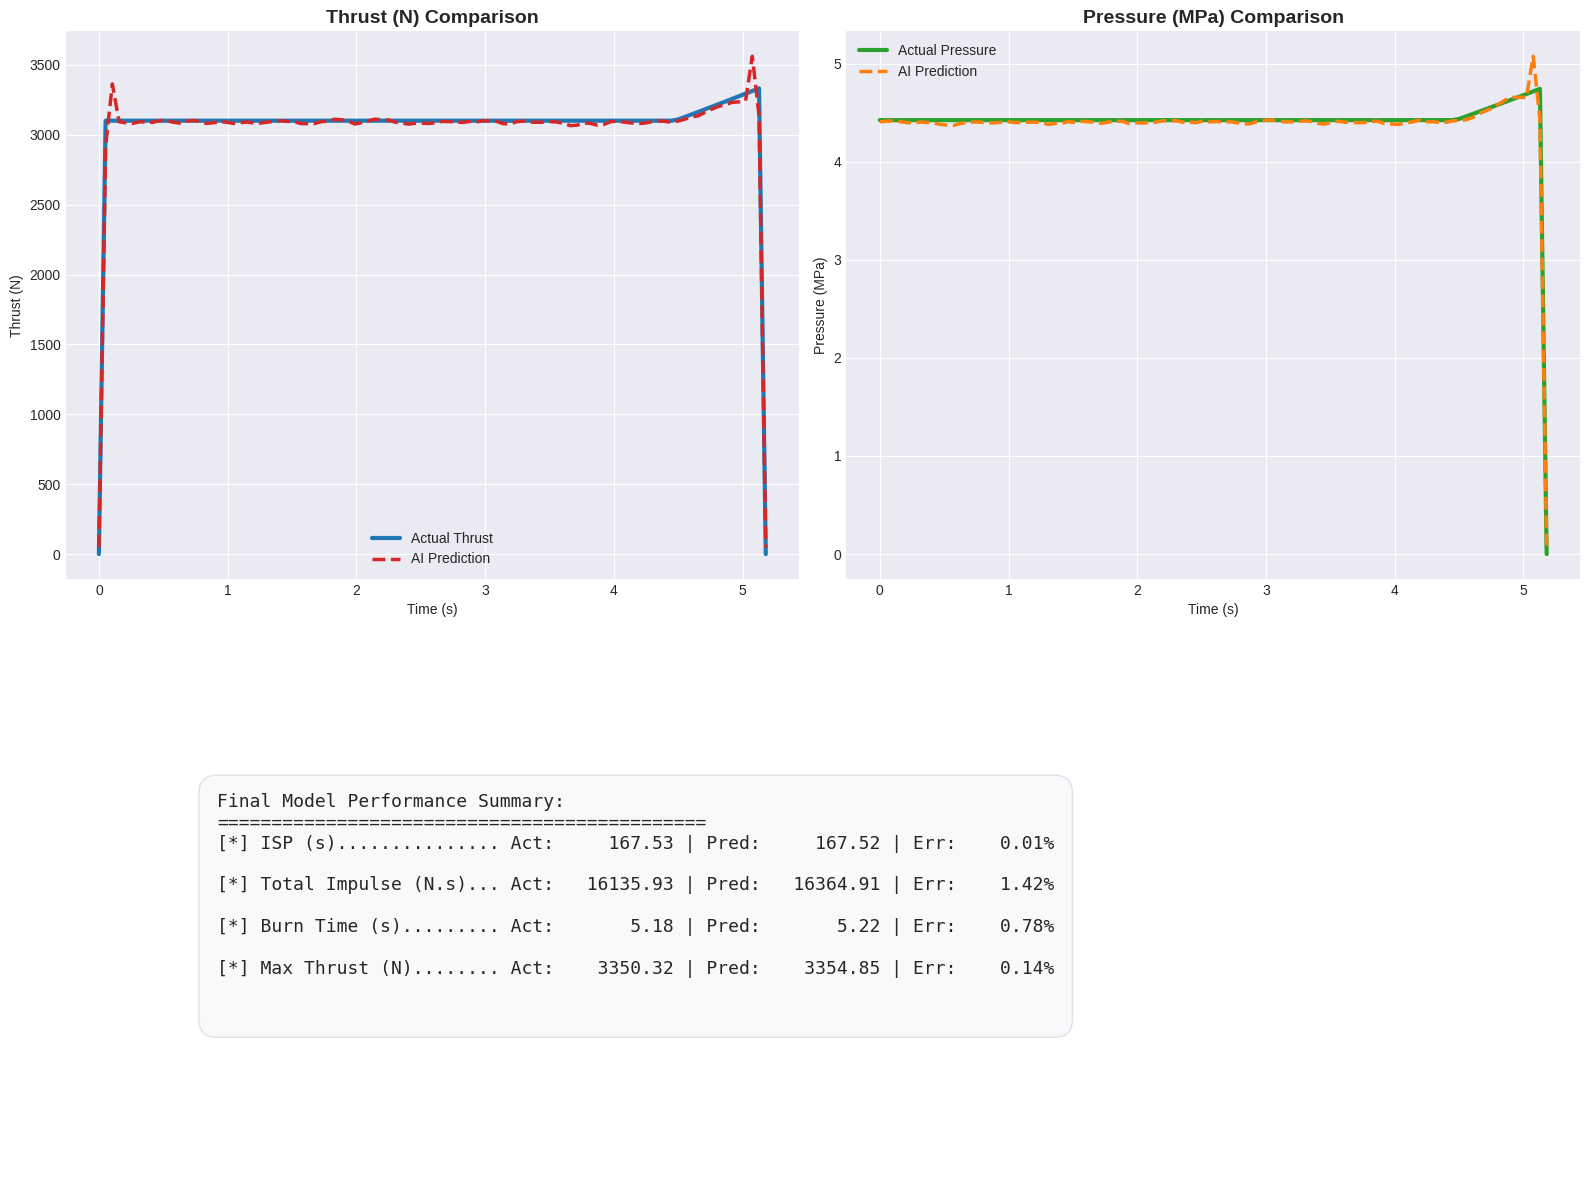

In [17]:
# 1. Select a sample index to visualize
sample_idx = 200 
sample_input = X_test_scaled[sample_idx:sample_idx+1]

# 2. Get predictions from the model
predictions = model.predict(sample_input)

# 3. Inverse transform predictions to real units
pred_thrust = scaler_t.inverse_transform(predictions[0][0].reshape(-1, 1)).flatten()
pred_pressure = scaler_p.inverse_transform(predictions[1][0].reshape(-1, 1)).flatten()
pred_scalars = scaler_Ys.inverse_transform(predictions[2])[0] 

# 4. Get Actual values
act_thrust = scaler_t.inverse_transform(Yt_test[sample_idx].reshape(-1, 1)).flatten()
act_pressure = scaler_p.inverse_transform(Yp_test[sample_idx].reshape(-1, 1)).flatten()
act_scalars = Ys_test[sample_idx]

# 5. Setup time axis
burn_time_act = act_scalars[2]
time_axis = np.linspace(0, burn_time_act, 100)

# 6. Light smoothing for better visualization
pred_thrust_final = np.maximum(0, savgol_filter(pred_thrust, 5, 3))
pred_pressure_final = np.maximum(0, savgol_filter(pred_pressure, 5, 3))

# 7. Plotting
plt.figure(figsize=(16, 12))
plt.style.use('seaborn-v0_8-darkgrid')

# Thrust Plot
plt.subplot(2, 2, 1)
plt.plot(time_axis, act_thrust, color='#1f77b4', label='Actual Thrust', linewidth=3)
plt.plot(time_axis, pred_thrust_final, color='#d62728', linestyle='--', label='AI Prediction', linewidth=2.5)
plt.title('Thrust (N) Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Time (s)')
plt.ylabel('Thrust (N)')
plt.legend()

# Pressure Plot
plt.subplot(2, 2, 2)
plt.plot(time_axis, act_pressure, color='#2ca02c', label='Actual Pressure', linewidth=3)
plt.plot(time_axis, pred_pressure_final, color='#ff7f0e', linestyle='--', label='AI Prediction', linewidth=2.5)
plt.title('Pressure (MPa) Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Time (s)')
plt.ylabel('Pressure (MPa)')
plt.legend()

# Accuracy Summary Table (Replaced 🔹 with [*] to fix font error)
plt.subplot(2, 1, 2)
plt.axis('off')
labels = ['ISP (s)', 'Total Impulse (N.s)', 'Burn Time (s)', 'Max Thrust (N)']
summary_text = "Final Model Performance Summary:\n" + "="*45 + "\n"

for i, label in enumerate(labels):
    error = abs(pred_scalars[i] - act_scalars[i]) / (abs(act_scalars[i]) + 1e-9) * 100
    # Use standard characters like [*] instead of emojis
    summary_text += f"[*] {label:.<22} Act: {act_scalars[i]:>10.2f} | Pred: {pred_scalars[i]:>10.2f} | Err: {error:>7.2f}%\n\n"

plt.text(0.1, 0.5, summary_text, fontsize=13, family='monospace', va='center', 
         bbox=dict(facecolor='#f8f9fa', edgecolor='#dee2e6', boxstyle='round,pad=1'))

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
====== Predicted Motor Performance ======
ISP:            174.63 s
Total Impulse:  122849.15 Ns
Burn Time:      8.49 s
Max Thrust:     41742.23 N


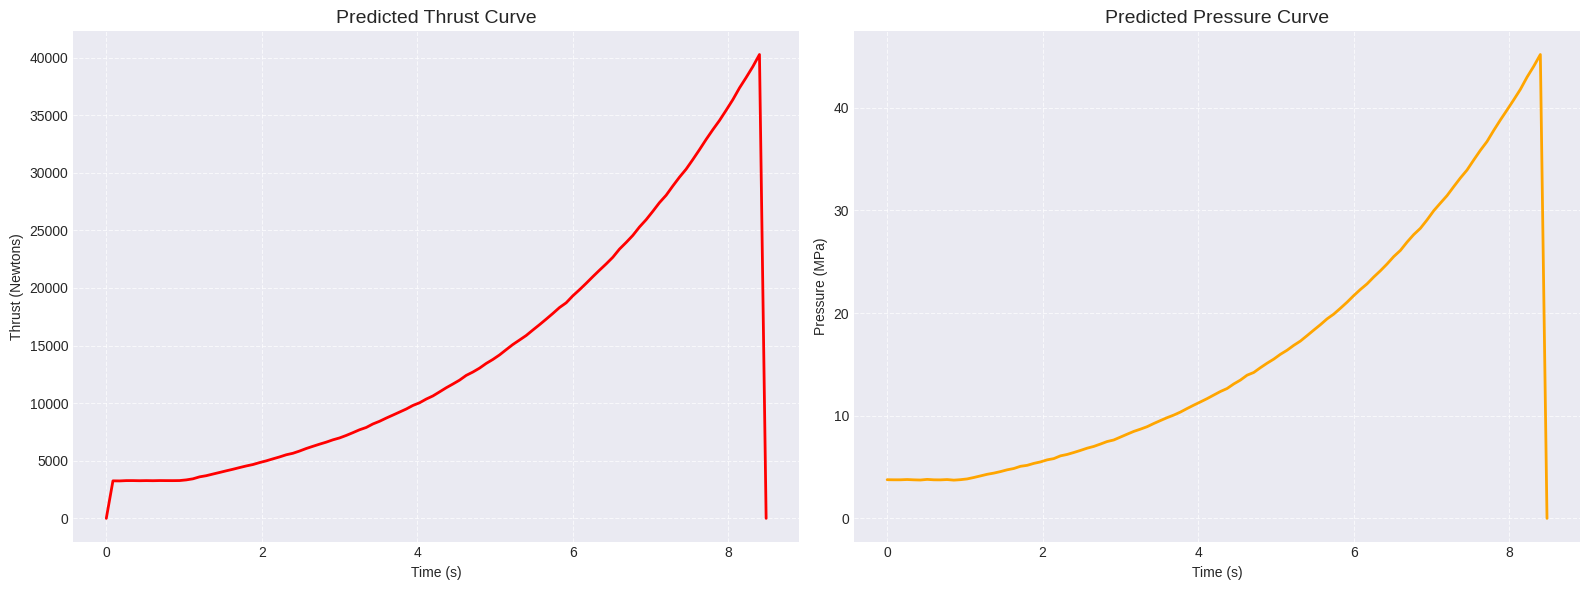

In [24]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_new_motor(model, scaler_x, scaler_y, scaler_t, scaler_p, custom_features):
    """
    custom_features: list of 7 dimensions
    ['Length', 'Diameter', 'Core_Diameter', 'Rod_Diameter', 'Support_Diameter', 'Throat_Diameter', 'Exit_Diameter']
    """
    # 1. Feature Engineering
    throat_dia = custom_features[5]
    exit_dia = custom_features[6]
    
    throat_area = np.pi * (throat_dia / 2)**2
    exit_area = np.pi * (exit_dia / 2)**2
    
    # 2. Prepare Input array (9 features)
    input_array = np.array(custom_features + [throat_area, exit_area]).reshape(1, -1)
    
    # 3. Scale Input
    input_scaled = scaler_x.transform(input_array)
    
    # 4. Predict
    preds = model.predict(input_scaled)
    
    # 5. Decode Predictions 
    thrust_curve = scaler_t.inverse_transform(preds[0]).flatten()
    pressure_curve = scaler_p.inverse_transform(preds[1]).flatten()
    
    scalars = scaler_y.inverse_transform(preds[2])[0]
    
    burn_time = scalars[2]
    time_axis = np.linspace(0, burn_time, 100)
    
    # 6. Print Metrics
    print("====== Predicted Motor Performance ======")
    print(f"ISP:            {scalars[0]:.2f} s")
    print(f"Total Impulse:  {scalars[1]:.2f} Ns")
    print(f"Burn Time:      {burn_time:.2f} s")
    print(f"Max Thrust:     {scalars[3]:.2f} N")
    print("=========================================")
    
    # 7. Plot Prediction
    plt.figure(figsize=(16, 6))
    
    plt.subplot(1, 2, 1)
    plt.plot(time_axis, thrust_curve, 'r-', linewidth=2)
    plt.title('Predicted Thrust Curve', fontsize=14)
    plt.xlabel('Time (s)')
    plt.ylabel('Thrust (Newtons)')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.subplot(1, 2, 2)
    plt.plot(time_axis, pressure_curve, 'orange', linewidth=2)
    plt.title('Predicted Pressure Curve', fontsize=14)
    plt.xlabel('Time (s)')
    plt.ylabel('Pressure (MPa)')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# Base custom design features (7 features)
my_design = [130, 20, 4, 1, 0, 2.9, 4.35]

simulate_new_motor(model, scaler_X, scaler_Ys, scaler_t, scaler_p, my_design)

In [26]:
import joblib

# Save the trained model 
model.save('X_Grain_Rocket_Model.keras')
print("✅ Model saved successfully as X_Grain_Rocket_Model.keras")

# Save Scalers for future use using correct exact variable names
joblib.dump(scaler_X, 'scaler_X.pkl')
joblib.dump(scaler_t, 'scaler_t.pkl')
joblib.dump(scaler_p, 'scaler_p.pkl')
joblib.dump(scaler_Ys, 'scaler_Ys.pkl')

print("✅ Scalers saved successfully.")

✅ Model saved successfully as X_Grain_Rocket_Model.keras
✅ Scalers saved successfully.


In [ ]:
import matplotlib.pyplot as plt

# Pick a random sample index
idx = 0 

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(y_t_train_final[idx].flatten())
plt.title("Synchronized Thrust Curve (100 Points)")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(y_p_train_final[idx].flatten(), color='orange')
plt.title("Synchronized Pressure Curve (100 Points)")
plt.grid(True)
plt.show()


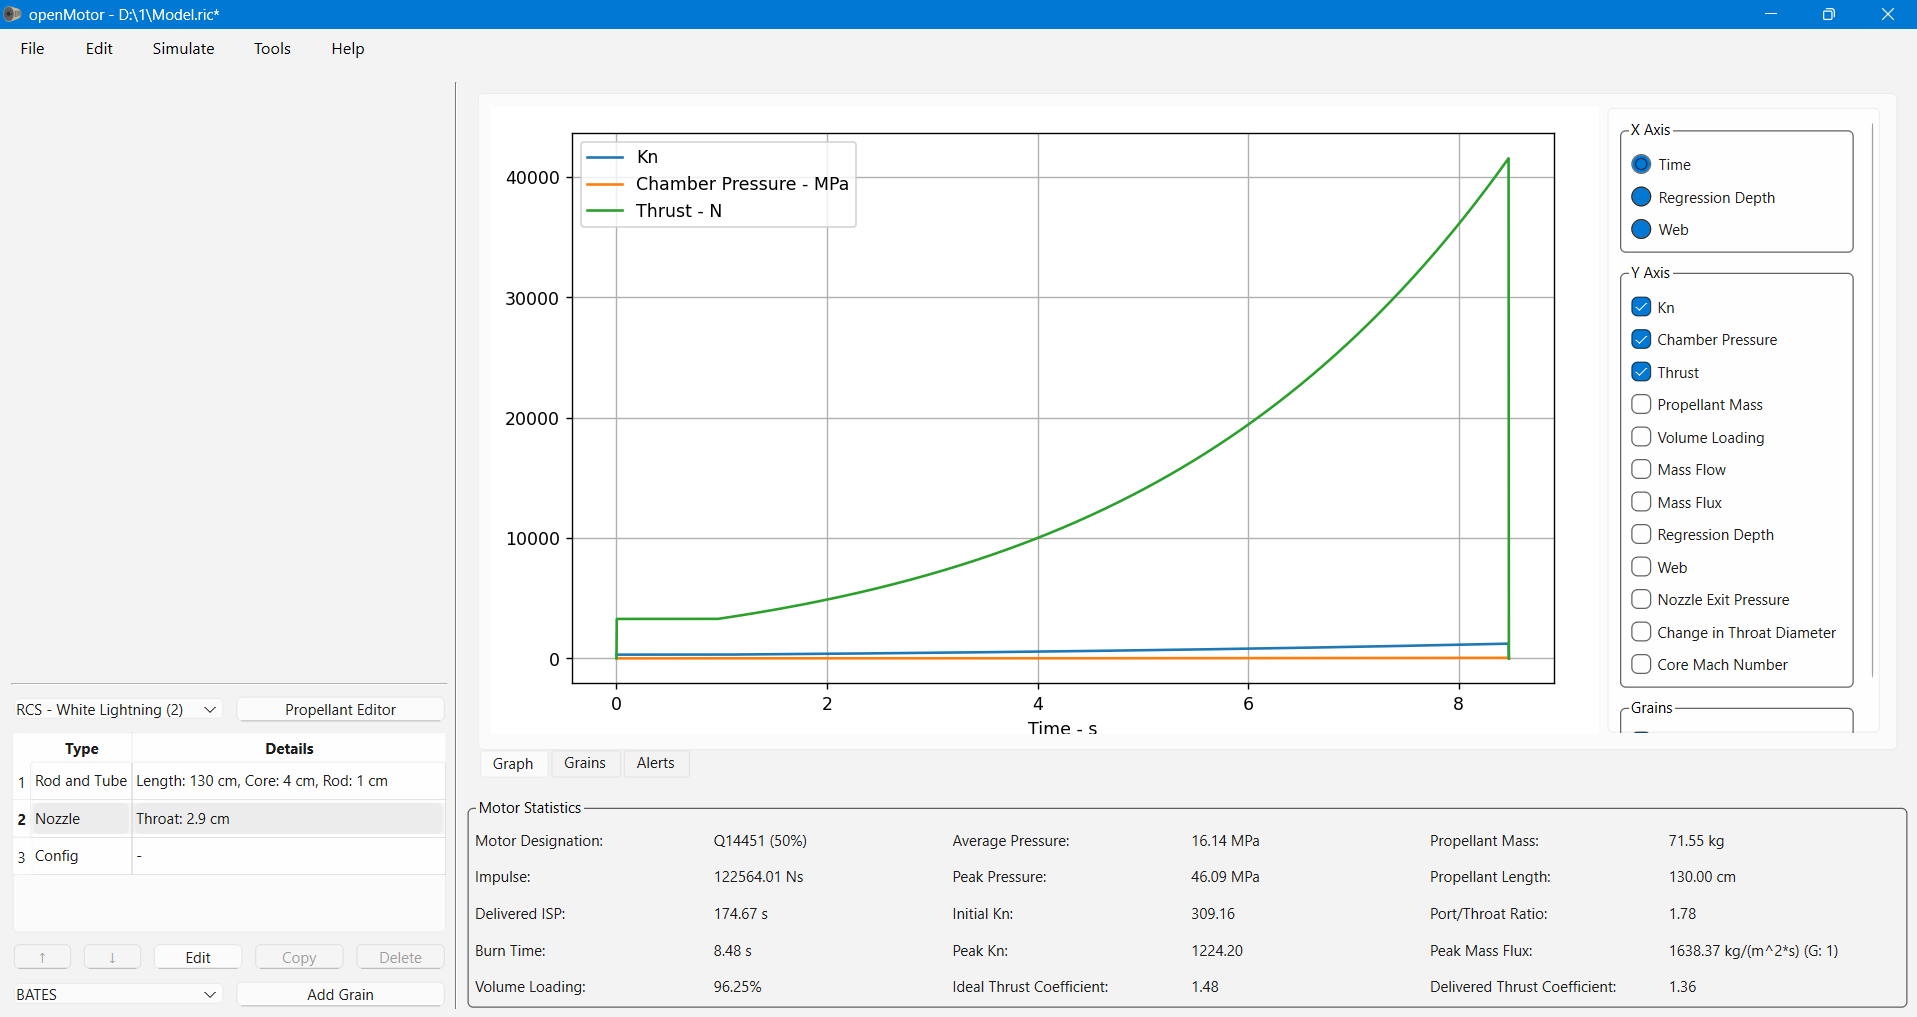